In [17]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
import numpy as np

# 24-hour cycle
df["sin_hour_1"] = np.sin(2 * np.pi * df["hour"] / 24)
df["cos_hour_1"] = np.cos(2 * np.pi * df["hour"] / 24)

# second harmonic (helps with morning + evening peaks)
df["sin_hour_2"] = np.sin(4 * np.pi * df["hour"] / 24)
df["cos_hour_2"] = np.cos(4 * np.pi * df["hour"] / 24)

# weekly periodicity
df["sin_week"] = np.sin(2*np.pi*df["week"]/52)
df["cos_week"] = np.cos(2*np.pi*df["week"]/52)

formula = """
ped ~
ped_lag1
+ ped_lag24
+ sin_hour_1
+ cos_hour_1
+ sin_hour_2
+ cos_hour_2
+ sin_week
+ cos_week
+ C(dow)
+ is_weekend
+ C(cluster_geo)
+ temp_c
+ wind_ms
+ rain_mm
+ Dark
+ Dark:C(cluster_geo)
+ safety_scaled
"""

model_cols = [
    "ped",
    "ped_lag1",
    "ped_lag24",
    "sin_hour_1",
    "cos_hour_1",
    "sin_hour_2",
    "cos_hour_2",
    "sin_week",
    "cos_week",
    "dow",
    "is_weekend",
    "cluster_geo",
    "temp_c",
    "wind_ms",
    "rain_mm",
    "Dark",
    "safety_scaled",
    "sensor_id"
]

df_m = df[model_cols].copy()
df_m = df_m.dropna().reset_index(drop=True)

print("Rows used in model:", len(df_m))
print("Unique sensors:", df_m["sensor_id"].nunique())

model = smf.glm(
    formula=formula,
    data=df_m,
    family=sm.families.NegativeBinomial()
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_m["sensor_id"].values}
)

print(model.summary())

Rows used in model: 376901
Unique sensors: 46
                 Generalized Linear Model Regression Results                  
Dep. Variable:                    ped   No. Observations:               376901
Model:                            GLM   Df Residuals:                   376877
Model Family:        NegativeBinomial   Df Model:                           23
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.7461e+06
Date:                Thu, 12 Mar 2026   Deviance:                   6.4271e+05
Time:                        10:06:33   Pearson chi2:                 6.03e+05
No. Iterations:                    45   Pseudo R-squ. (CS):             0.8433
Covariance Type:              cluster                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------

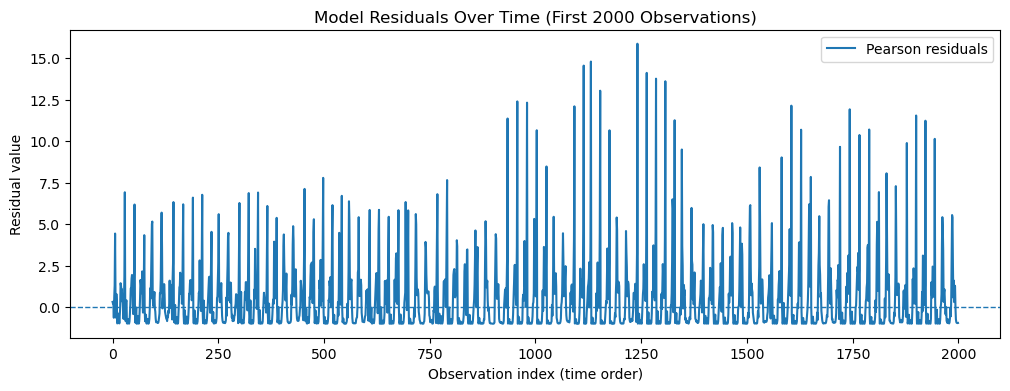

In [18]:
df_m["resid"] = model.resid_pearson

plt.figure(figsize=(12,4))
plt.plot(df_m["resid"].values[:2000], label="Pearson residuals")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Observation index (time order)")
plt.ylabel("Residual value")
plt.title("Model Residuals Over Time (First 2000 Observations)")
plt.legend()
plt.show()

<Figure size 1000x500 with 0 Axes>

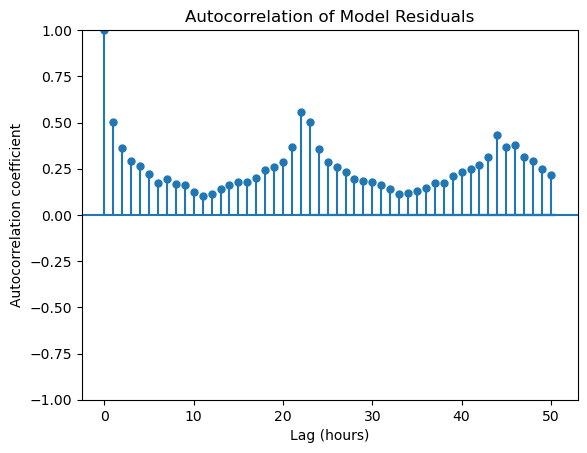

In [19]:
plt.figure(figsize=(10,5))
plot_acf(df_m["resid"], lags=50)
plt.xlabel("Lag (hours)")
plt.ylabel("Autocorrelation coefficient")
plt.title("Autocorrelation of Model Residuals")
plt.show()

In [20]:
dark_coef = model.params["Dark"]
dark_effect = (np.exp(dark_coef) - 1) * 100
print("Darkness effect (% change):", dark_effect)

Darkness effect (% change): -61.594734876171664


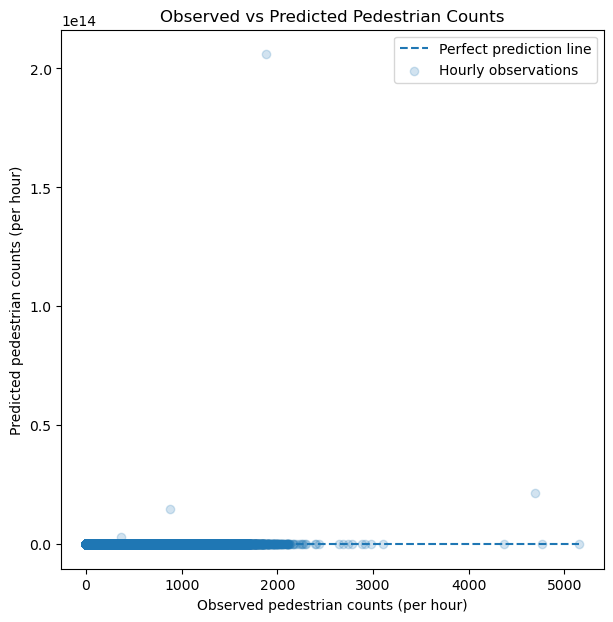

In [21]:
plt.figure(figsize=(7,7))

plt.scatter(
    df_m["ped"],
    model.fittedvalues,
    alpha=0.2,
    label="Hourly observations"
)

plt.xlabel("Observed pedestrian counts (per hour)")
plt.ylabel("Predicted pedestrian counts (per hour)")

plt.title("Observed vs Predicted Pedestrian Counts")

plt.plot(
    [df_m["ped"].min(), df_m["ped"].max()],
    [df_m["ped"].min(), df_m["ped"].max()],
    linestyle="--",
    label="Perfect prediction line"
)

plt.legend()

plt.show()

In [22]:
import numpy as np

coef = model.params

dark0 = coef["Dark"]

dark1 = coef["Dark"] + coef.get("Dark:C(cluster_geo)[T.1]",0)

dark2 = coef["Dark"] + coef.get("Dark:C(cluster_geo)[T.2]",0)

effects = {
    "Cluster 0": (np.exp(dark0)-1)*100,
    "Cluster 1": (np.exp(dark1)-1)*100,
    "Cluster 2": (np.exp(dark2)-1)*100
}

print("Darkness effect by cluster (% change):")
print(effects)

Darkness effect by cluster (% change):
{'Cluster 0': -61.594734876171664, 'Cluster 1': -58.040256043939856, 'Cluster 2': -31.905755509209822}
